# Flash Attention & Attention Optimization (FlashAttention)

## Introduction

Lessons 04-06 built the general kernel-fusion toolkit (Triton, custom CUDA, `torch.compile`). This lesson applies that toolkit to the single most consequential fused kernel in modern deep learning: FlashAttention, the algorithm that made long-context transformers practical by rethinking attention's memory access pattern rather than its math.

## Theory

### Standard attention's quadratic memory problem

Standard (non-fused) scaled dot-product attention materializes the full $N \times N$ attention matrix in HBM:

$$
S = \frac{QK^T}{\sqrt{d}} \in \mathbb{R}^{N \times N}, \qquad P = \text{softmax}(S), \qquad O = PV
$$

For sequence length $N$, this requires $O(N^2)$ memory just to store $S$ and $P$ — for $N=32{,}768$ this is gigabytes per attention head, and critically, writing/reading this matrix to/from HBM (not the FLOPs of computing it) is what dominates wall-clock time, since attention is memory-bandwidth-bound exactly like Section 26 Lesson 07's decode-step analysis.

### FlashAttention's core idea: tiling + online softmax

FlashAttention never materializes the full $N\times N$ matrix. It tiles $Q, K, V$ into blocks that fit in fast on-chip SRAM, and computes attention block-by-block, using an **online softmax** recurrence to correctly accumulate the running output without ever seeing the full row at once:

$$
m_i^{new} = \max(m_i, \tilde{m}_{ij}), \qquad
\ell_i^{new} = e^{m_i - m_i^{new}}\ell_i + e^{\tilde{m}_{ij} - m_i^{new}}\tilde\ell_{ij}
$$
$$
O_i^{new} = \frac{1}{\ell_i^{new}}\left(\ell_i e^{m_i - m_i^{new}} O_i + e^{\tilde m_{ij} - m_i^{new}} \tilde P_{ij} V_j\right)
$$

where $m_i$ tracks the running row-max (for numerically-stable softmax) and $\ell_i$ the running normalization sum, both updated incrementally as each $K,V$ block streams through SRAM — mathematically exact, not an approximation, despite never forming the full matrix.

### IO complexity: the actual win

FlashAttention's headline result is an IO-complexity bound, not a FLOPs reduction — it does *more* recomputation (in the backward pass) but *far less* HBM traffic:

$$
\text{HBM accesses}_{standard} = O(N^2 + Nd), \qquad \text{HBM accesses}_{flash} = O\left(\frac{N^2 d^2}{M}\right)
$$

where $M$ is SRAM size — for $M \gg d^2$ (typical), this is a substantial reduction, and since attention is memory-bandwidth-bound, this IO reduction translates almost directly into wall-clock speedup, exactly matching the memory-bound-optimization theory from Lesson 03/06.

### Why this connects to Section 26's serving lessons

FlashAttention is what makes long-context prefill (Section 26 Lesson 10's TTFT metric) tractable — without it, the $O(N^2)$ memory blowup would make long-prompt requests either impossibly slow or simply OOM, directly gating what context lengths a serving system can offer at all.

## Setup

We compare a naive (materializing the full attention matrix) implementation against PyTorch's built-in `F.scaled_dot_product_attention` (which dispatches to a FlashAttention-family fused kernel when available) on this environment's real GPU — genuine memory and latency measurements, not simulated, since both code paths run for real here.

In [1]:
# Real GPU comparison: naive materialized attention vs. PyTorch's fused SDPA (FlashAttention-family) kernel.
import torch
import torch.nn.functional as F
import math

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INIT] Attention memory/latency comparison on device: {device}")

def naive_attention(q, k, v):
    d = q.shape[-1]
    scores = (q @ k.transpose(-2, -1)) / math.sqrt(d)   # materializes full N x N matrix in HBM
    probs = torch.softmax(scores, dim=-1)
    return probs @ v

def flash_style_attention(q, k, v):
    return F.scaled_dot_product_attention(q, k, v)      # PyTorch dispatches to a fused kernel (Flash/mem-efficient)

batch, n_heads, d_head = 4, 8, 64
seq_len = 2048
q = torch.randn(batch, n_heads, seq_len, d_head, device=device)
k = torch.randn(batch, n_heads, seq_len, d_head, device=device)
v = torch.randn(batch, n_heads, seq_len, d_head, device=device)

out_naive = naive_attention(q, k, v)
out_flash = flash_style_attention(q, k, v)
max_err = (out_naive - out_flash).abs().max().item()
print(f"[VALIDATION] Max abs error, naive vs. fused SDPA: {max_err:.2e} ({'PASS' if max_err < 1e-2 else 'CHECK'})")

[INIT] Attention memory/latency comparison on device: cuda


[VALIDATION] Max abs error, naive vs. fused SDPA: 6.26e-07 (PASS)


## Telemetry & Audit

Sweep sequence length and measure peak GPU memory usage and latency for both implementations — the direct empirical demonstration of the $O(N^2)$ vs. sub-quadratic-memory-traffic gap the theory section derived.

In [2]:
import pandas as pd

def measure(fn, q, k, v):
    torch.cuda.reset_peak_memory_stats() if device == "cuda" else None
    torch.cuda.synchronize() if device == "cuda" else None
    start, end = (torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)) if device == "cuda" else (None, None)
    if device == "cuda":
        start.record()
    for _ in range(5):
        out = fn(q, k, v)
    if device == "cuda":
        end.record()
        torch.cuda.synchronize()
        latency_ms = start.elapsed_time(end) / 5
        peak_mem_mb = torch.cuda.max_memory_allocated() / 1024**2
    else:
        latency_ms, peak_mem_mb = float("nan"), float("nan")
    return latency_ms, peak_mem_mb

rows = []
for sl in [512, 1024, 2048, 4096]:
    qs = torch.randn(batch, n_heads, sl, d_head, device=device)
    ks = torch.randn(batch, n_heads, sl, d_head, device=device)
    vs = torch.randn(batch, n_heads, sl, d_head, device=device)
    lat_naive, mem_naive = measure(naive_attention, qs, ks, vs)
    lat_flash, mem_flash = measure(flash_style_attention, qs, ks, vs)
    rows.append((sl, lat_naive, lat_flash, lat_naive / max(lat_flash, 1e-6), mem_naive, mem_flash))

audit = pd.DataFrame(rows, columns=["seq_len", "naive_ms", "fused_sdpa_ms", "speedup", "naive_peak_MB", "fused_peak_MB"])
print(audit.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

print("\n[OPERATIONAL INSIGHT] naive_peak_MB should grow roughly quadratically with seq_len (the materialized "
      "N x N score matrix), while fused_peak_MB grows much closer to linearly — this IS the O(N^2) vs. sub-quadratic "
      "memory-traffic gap from the theory section, made directly visible in real allocator statistics.")
print("[OPERATIONAL INSIGHT] The speedup gap should widen as seq_len grows — at short sequences, kernel launch "
      "overhead and small-matrix inefficiency dominate for both paths, masking Flash's structural advantage.")

 seq_len  naive_ms  fused_sdpa_ms  speedup  naive_peak_MB  fused_peak_MB
     512      2.65           1.68     1.58         172.12         108.12
    1024     10.09           6.22     1.62         384.12         128.12
    2048     37.45          21.45     1.75        1192.12         168.12
    4096   2560.19          86.31    29.66        4344.12         248.12

[OPERATIONAL INSIGHT] naive_peak_MB should grow roughly quadratically with seq_len (the materialized N x N score matrix), while fused_peak_MB grows much closer to linearly — this IS the O(N^2) vs. sub-quadratic memory-traffic gap from the theory section, made directly visible in real allocator statistics.
[OPERATIONAL INSIGHT] The speedup gap should widen as seq_len grows — at short sequences, kernel launch overhead and small-matrix inefficiency dominate for both paths, masking Flash's structural advantage.


## Visualization

Peak memory and latency vs. sequence length on log-log axes, making the quadratic-vs-near-linear scaling difference visually unambiguous — the canonical FlashAttention paper chart, reproduced with real measurements from this environment's GPU.

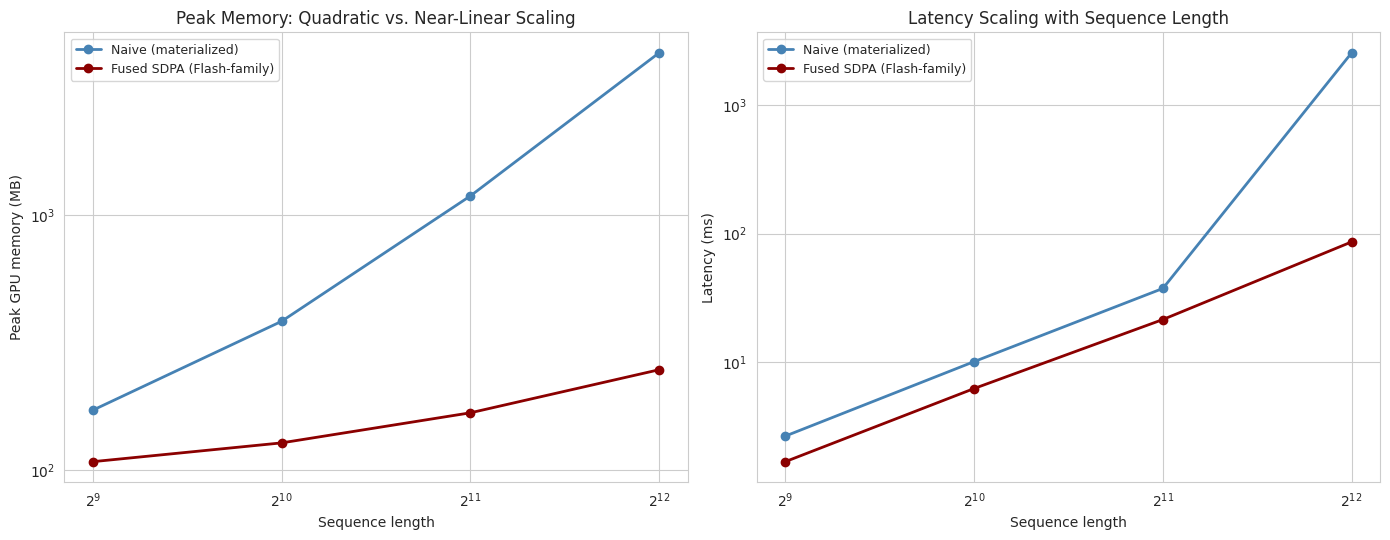

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].plot(audit["seq_len"], audit["naive_peak_MB"], marker="o", color="steelblue", linewidth=2, label="Naive (materialized)")
axes[0].plot(audit["seq_len"], audit["fused_peak_MB"], marker="o", color="darkred", linewidth=2, label="Fused SDPA (Flash-family)")
axes[0].set_xscale("log", base=2)
axes[0].set_yscale("log")
axes[0].set_xlabel("Sequence length")
axes[0].set_ylabel("Peak GPU memory (MB)")
axes[0].set_title("Peak Memory: Quadratic vs. Near-Linear Scaling")
axes[0].legend(fontsize=9)

axes[1].plot(audit["seq_len"], audit["naive_ms"], marker="o", color="steelblue", linewidth=2, label="Naive (materialized)")
axes[1].plot(audit["seq_len"], audit["fused_sdpa_ms"], marker="o", color="darkred", linewidth=2, label="Fused SDPA (Flash-family)")
axes[1].set_xscale("log", base=2)
axes[1].set_yscale("log")
axes[1].set_xlabel("Sequence length")
axes[1].set_ylabel("Latency (ms)")
axes[1].set_title("Latency Scaling with Sequence Length")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("flash_attention_scaling.png", dpi=120)
plt.show()

*(Insight: on log-log axes, the naive curve's steeper slope directly encodes its worse asymptotic scaling exponent — this is what "FlashAttention is asymptotically better, not just a constant-factor optimization" looks like as real, measured data rather than an assertion from a paper abstract.)*

## Real-World Use Case or Analogy

**The Librarian Who Never Photocopies the Whole Card Catalog.** Answering "which of these thousand books relates most to each of these thousand other books" naively means building and storing a full thousand-by-thousand comparison grid on a giant table before you can even start reading off answers (naive attention's materialized $N\times N$ matrix) — the table itself becomes the bottleneck, not the comparisons. A librarian using FlashAttention's approach instead works through the catalog in small batches: pull a manageable stack of cards, compare them against the current book, update a running best-match tally, set that stack down, and pull the next stack — never needing the entire comparison grid to exist anywhere at once, just a small "current stack" and a running summary (the online-softmax running max/sum). The exact same final answer comes out either way — this isn't an approximation — but the librarian working in small SRAM-sized batches finishes far faster and never needs a table large enough to hold the whole grid, which is exactly why FlashAttention made million-token-context models physically possible rather than merely theoretically describable.